In [44]:
import pandas as pd
import optuna
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import shap
import wandb
from Optune_simulation_env import get_best_params, walk_forward_predict_test
from utils import load_data
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
import glob
import re

In [45]:
COUNTRY = "HR"
MODEL = "xgboost"

In [46]:
def confidence_interval(diff, alpha=0.05):
    mean = np.mean(diff)
    std = np.std(diff, ddof=1)
    n = len(diff)

    from scipy.stats import t
    t_val = t.ppf(1 - alpha/2, df=n-1)

    margin = t_val * std / np.sqrt(n)
    return mean, mean - margin, mean + margin


def cohens_d(diff):
    return diff.mean() / diff.std(ddof=1)

In [47]:
def plot_paper_results(real, methods, metric="RMSE"):
    
    names = list(methods.keys())
    arrays = list(methods.values())

    means = [real.mean()] + [m.mean() for m in arrays]

    # CI computation
    def ci(a):
        m = np.mean(a)
        se = np.std(a, ddof=1) / np.sqrt(len(a))
        ci = 1.96 * se
        return m, ci

    real_m, real_ci = ci(real)

    cis = [real_ci]
    for m in arrays:
        _, c = ci(m)
        cis.append(c)

    labels = ["Real"] + names

    # -----------------------
    # Mean + CI Bar Plot
    # -----------------------
    plt.figure(figsize=(6,4))

    x = np.arange(len(means))

    plt.bar(x, means, yerr=cis, capsize=5)

    plt.xticks(x, labels)
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison (Mean ±95% CI)")

    plt.tight_layout()
    plt.savefig(f"outputs/{COUNTRY}/Images_{MODEL}_{metric}_{COUNTRY}_compare.svg", format="svg")
    plt.show()
    plt.close()

    # -----------------------
    # Improvement Plot
    # -----------------------
    diffs = [m - real for m in arrays]

    plt.figure(figsize=(6,4))

    plt.boxplot(diffs)

    plt.axhline(0, linestyle="--")

    plt.xticks(range(1, len(names)+1), names)

    plt.ylabel(f"{metric} Difference vs Real")

    plt.title(f"Paired {metric} Improvements")

    plt.tight_layout()
    plt.savefig(f"outputs/{COUNTRY}/Images_{MODEL}_{metric}_{COUNTRY}_improvement.svg", format="svg")
    plt.show()
    plt.close()

In [48]:
def evaluate_metric(results: dict, metric="rmse", plot=True):
    """
    metric: 'rmse' or 'mae'
    """
    # Select correct arrays
    real = results["real"][metric]
    lgbm = results["synth_lgbm"][metric]
    spline = results["synth_spline"][metric]
    intra = results["synth_intra"][metric]

    methods = {
        "Synth LGBM": lgbm,
        "Spline": spline,
        "Intra": intra
    }

    rows = []

    for name, method in methods.items():
        diff = method - real

        mean_metric = method.mean()
        mean_diff, ci_low, ci_high = confidence_interval(diff)
        stat, p = ttest_rel(method, real)
        d = cohens_d(diff)

        rows.append({
            "method": name,
            f"{metric}_mean": mean_metric,
            "diff_mean": mean_diff,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": p,
            "effect_size_d": d
        })

    df = pd.DataFrame(rows)

    # Multiple testing correction
    reject, pvals_corrected, _, _ = multipletests(df["p_value"], method='holm')
    df["p_corrected"] = pvals_corrected
    df["significant"] = reject

    # Improvement %
    df["improvement_%"] = 100 * (-df["diff_mean"] / real.mean())

    # Pretty display
    df_display = df.copy()
    df_display[f"{metric}_mean"] = df_display[f"{metric}_mean"].round(4)
    df_display["diff_mean"] = df_display["diff_mean"].round(4)
    df_display["ci_low"] = df_display["ci_low"].round(4)
    df_display["ci_high"] = df_display["ci_high"].round(4)
    df_display["p_value"] = df_display["p_value"].apply(lambda x: f"{x:.2e}")
    df_display["p_corrected"] = df_display["p_corrected"].apply(lambda x: f"{x:.2e}")
    df_display["effect_size_d"] = df_display["effect_size_d"].round(3)
    df_display["improvement_%"] = df_display["improvement_%"].round(2)

    print(f"\n===== {metric.upper()} RESULTS =====")
    df_display.to_csv(f"outputs/{COUNTRY}/{MODEL}_{metric}.csv", index=False)
    # ----------------
    # Plots
    # ----------------
    if plot:
        plot_paper_results(
        real,
        methods,
        metric=metric.upper()
    )

    return df

In [49]:
def load_metric(model, dataset, metric, country="PL"):

    pattern = f"outputs/{country}/{model}_run*_{dataset}_{metric}.npy"
    files = sorted(glob.glob(pattern))

    return np.array([np.load(f) for f in files])

In [50]:
results_real_rmse = load_metric(MODEL, "real", "rmse")
results_synth_lgbm_rmse = load_metric(MODEL, "lgbm", "rmse")
results_synth_spline_rmse = load_metric(MODEL, "spline", "rmse")
results_synth_intra_rmse = load_metric(MODEL, "intra", "rmse")
results_real_mae = load_metric(MODEL, "real", "mae")
results_synth_lgbm_mae = load_metric(MODEL, "lgbm", "mae")
results_synth_spline_mae = load_metric(MODEL, "spline", "mae")
results_synth_intra_mae = load_metric(MODEL, "intra", "mae")

In [51]:
print(len(results_real_rmse))

17


In [52]:
results = {
        "real": {"rmse": results_real_rmse, "mae": results_real_mae},
        "synth_lgbm": {"rmse": results_synth_lgbm_rmse, "mae": results_synth_lgbm_mae},
        "synth_spline": {"rmse": results_synth_spline_rmse, "mae": results_synth_spline_mae},
        "synth_intra": {"rmse": results_synth_intra_rmse, "mae": results_synth_intra_mae}
    }


===== RMSE RESULTS =====


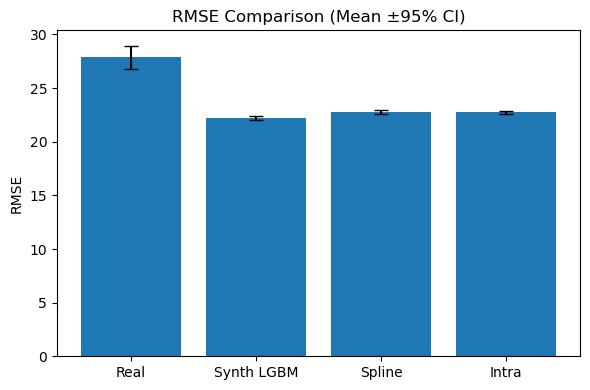

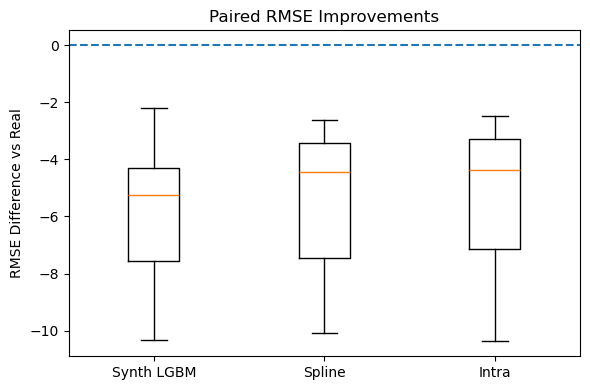

,method,rmse_mean,diff_mean,ci_low,ci_high,p_value,effect_size_d,p_corrected,significant,improvement_%
0,Synth LGBM,22.215726,-5.657942,-6.839564,-4.476320,2.229836e-08,-2.461908,6.689508e-08,True,20.298521
1,Spline,22.771541,-5.102128,-6.245873,-3.958383,5.941572e-08,-2.293581,1.188314e-07,True,18.304471
2,Intra,22.734787,-5.138881,-6.326846,-3.950917,9.039415e-08,-2.224114,1.188314e-07,True,18.436329


In [53]:
evaluate_metric(results, metric="rmse", plot=True)


===== MAE RESULTS =====


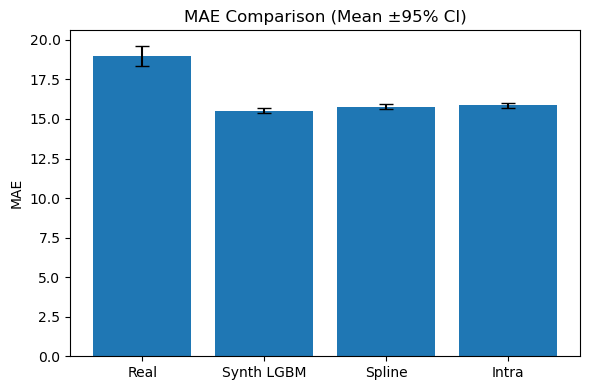

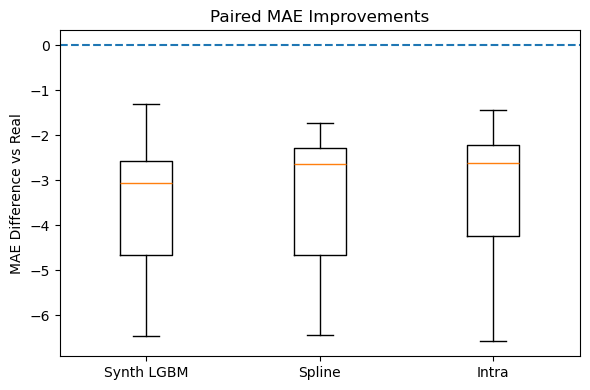

,method,mae_mean,diff_mean,ci_low,ci_high,p_value,effect_size_d,p_corrected,significant,improvement_%
0,Synth LGBM,15.535179,-3.434738,-4.170504,-2.698971,3.175252e-08,-2.400191,9.525755e-08,True,18.106235
1,Spline,15.777754,-3.192162,-3.881515,-2.502810,3.551686e-08,-2.380869,9.525755e-08,True,16.827498
2,Intra,15.875116,-3.094800,-3.838487,-2.351114,1.525015e-07,-2.139610,1.525015e-07,True,16.314253


In [54]:
evaluate_metric(results, metric="mae", plot=True)